# TI3145TU Midterm Assignment 
## Football Players Wages

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [2]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, MinMaxScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt


import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
    module="sklearn.linear_model._stochastic_gradient"
)


### Load data

In [3]:
# These are your training samples along with their labels
data = pd.read_csv('football_wages.csv')
print("features", data.columns)
data.info()


features Index(['age', 'height_cm', 'weight_kg', 'nationality_name', 'overall',
       'potential', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'defending_standing_tackle',
       'defending_sliding_tackle', 'goalkeeping_diving',
       'goalkeeping_handling', 'goalkeeping_kicking',
       'goalkeeping_positioning', 'goalkeeping_reflexes', 'log_wages'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   float64
 1   height_cm     

In [4]:
data.head()

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,log_wages
0,27.0,183.0,76.0,b'Korea Republic',57.0,58.0,54.0,30.0,55.0,53.0,...,60.0,67.0,63.0,58.0,9.0,13.0,8.0,11.0,10.0,3.000000
1,21.0,182.0,70.0,b'France',61.0,72.0,58.0,63.0,46.0,62.0,...,47.0,65.0,31.0,33.0,9.0,11.0,9.0,12.0,11.0,3.000000
2,35.0,182.0,75.0,b'Korea Republic',68.0,68.0,62.0,68.0,68.0,70.0,...,61.0,69.0,36.0,40.0,8.0,12.0,7.0,12.0,6.0,3.301030
3,29.0,169.0,70.0,b'Paraguay',67.0,67.0,62.0,55.0,50.0,71.0,...,59.0,84.0,40.0,55.0,6.0,10.0,11.0,15.0,9.0,2.698970
4,30.0,176.0,74.0,b'Austria',65.0,65.0,63.0,49.0,53.0,63.0,...,58.0,75.0,65.0,64.0,12.0,15.0,10.0,8.0,10.0,3.477121


### 1-3. Pre-processing Pipelines

In [5]:
# You need to extract the features and the regression target. The regression target is 'log_wages'. 
regression_target_Y = data["log_wages"]
features_X = data.drop(["log_wages"], axis=1)

numerical_features_X = features_X.select_dtypes(include=['number']).columns
categorical_features_X = features_X.select_dtypes(include=['object']).columns

# https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#
# A1) Basic Pipeline: (standardization of data)
numeric_transformer = Pipeline([('scaler', RobustScaler())])
# categorical_transformer = Pipeline([('one-hot', OneHotEncoder(handle_unknown="ignore"))])
categorical_transformer = Pipeline([('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                                    ('minmax', MinMaxScaler(feature_range=(-1, 1)))])
preprocesser_ct = ColumnTransformer(transformers=[
    ('numerical', numeric_transformer, numerical_features_X),
    ('categorical', categorical_transformer, categorical_features_X)
])

X_transformed = preprocesser_ct.fit_transform(features_X)

In [6]:
# Pipeline #2) Flipping the GoalKeepers
class flipKeepers(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        return None
    
    def fit(self, X, y=None):
        # Nothing to learn, so just return self
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns = self.columns)
        X_copy = X.copy()
        for col in [col for col in X.columns if 'goalkeeping' in col]:   
            avg = X[col].mean()
            X[col] = 2*avg - X_copy[col]
        return X

In [7]:
# You need to extract the features and the regression target. The regression target is 'log_wages'. 

def categorical_features(X):
     return X.select_dtypes(include=['object']).columns

regression_target_Y = data["log_wages"]
features_X = data.drop(["log_wages"], axis=1)

numerical_features_X = features_X.columns


categorical_transformer = ColumnTransformer(transformers=[
    ('target', TargetEncoder(), categorical_features)  
], remainder='passthrough')

# https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#
# A1) Basic Pipeline: (standardization of data)
# categorical_transformer = Pipeline([('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
#                                     ('minmax', MinMaxScaler(feature_range=(-1, 1)))])

preprocesser_dumb_cat = Pipeline([
    ('categorical', categorical_transformer)
])
preprocesser_simple = Pipeline([
    ('categorical', categorical_transformer),
    ('numerical', StandardScaler())
])
preprocesser_flip = Pipeline([
    ('categorical', categorical_transformer),
    ('flip', flipKeepers(numerical_features_X)),
    ('numerical', StandardScaler())
])
preprocesser_pca = Pipeline([
    ('categorical', categorical_transformer),
    ('numerical', StandardScaler()),
    ('pca', PCA(n_components=0.95))
])

<Figure size 640x480 with 0 Axes>

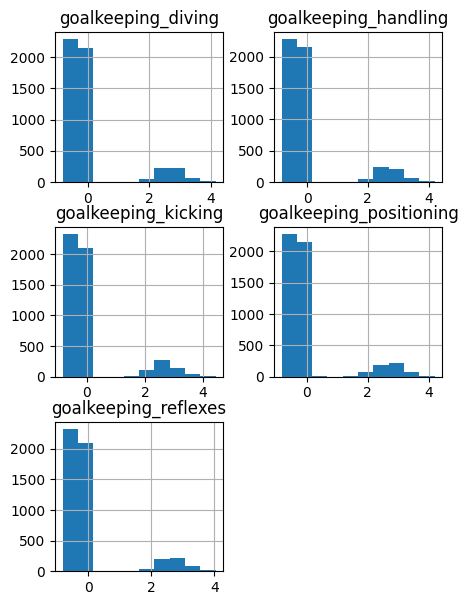

<Figure size 640x480 with 0 Axes>

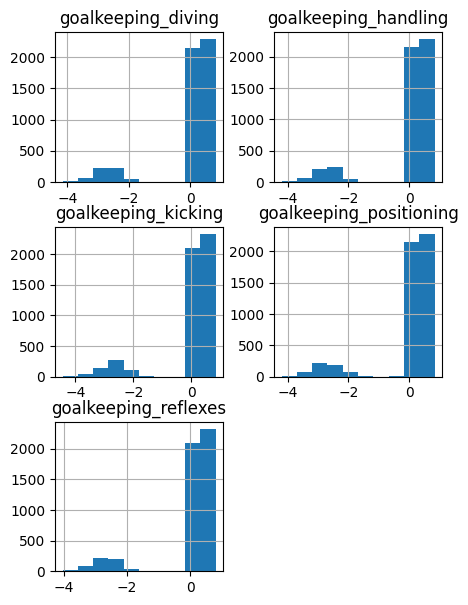

In [8]:
# Experiment with flipping the goalkeeper statistics 
X_transformed = pd.DataFrame(preprocesser_simple.fit_transform(features_X, regression_target_Y), 
                             columns=numerical_features_X)

goal = [col for col in X_transformed.columns if 'goalkeeping' in col]

plt.clf()
X_transformed[goal].hist(figsize=(5, 7))
plt.show()

X_transformed = pd.DataFrame(preprocesser_flip.fit_transform(features_X, regression_target_Y), 
                             columns=numerical_features_X)

goal = [col for col in X_transformed.columns if 'goalkeeping' in col]

plt.clf()
X_transformed[goal].hist(figsize=(5,7))
plt.show()


In [9]:
# Evaluate

#regressor = SGDRegressor()
#regressor = KNeighborsRegressor(3)

regressor = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    learning_rate='adaptive',
    eta0=0.01,
    alpha=0.00001
)


clf_dumb = Pipeline(
    steps=[("preprocessor", preprocesser_dumb_cat),
            ("regressor", regressor)]
)
clf = Pipeline(
    steps=[("preprocessor", preprocesser_simple),
            ("regressor", regressor)]
)
clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", regressor)]
)
clf_pca = Pipeline(
    steps=[("preprocessor", preprocesser_pca),
            ("regressor", regressor)]
)
for model, name in zip([clf_dumb, clf, clf_flip, clf_pca],['dumb', 'simple', 'flip', 'pca']):
    model_score_results = []
    for i in range(100):

        X_train, X_test, y_train, y_test = train_test_split(
            features_X, regression_target_Y, test_size=0.2, random_state=0
        )

        model.fit(X_train, y_train)
        model_score_results.append(model.score(X_test, y_test))
    print(model_score_results)
    print(f"{name}_score avg", sum(model_score_results) / len(model_score_results))
    print()

[-1.2455532140760564e+19, -3.0782009555093925e+21, -1.5681860778450234e+21, -6.51525870011451e+21, -2.1381981286939917e+21, -1.4495320194624633e+20, -1.7027544268180341e+21, -6.489443473147279e+21, -3.560908887787488e+22, -8.232298794141963e+20, -2.8962504095196774e+21, -2.294367832725929e+22, -9.813515063050708e+22, -4.031766699226376e+21, -1.1045810556811027e+18, -5.910839788935362e+21, -2.160844660876939e+22, -3.208930638057897e+22, -1.2015018355009706e+21, -6.138143048868537e+21, -6.750592438575562e+22, -1.9788079433983386e+22, -1.2127452473724983e+23, -7.826118119264854e+22, -2.9144909314730704e+22, -1.2002270481854903e+21, -1.825509843581543e+23, -2.415341070666272e+22, -1.0491534168227393e+23, -5.704870652040876e+21, -1.257202288771485e+23, -3.328312539600417e+22, -1.0336328619759868e+22, -1.7273061932545842e+23, -4.605072661842105e+22, -1.313749275315222e+21, -8.816554484387441e+21, -8.149779653433093e+22, -3.625346455270985e+18, -2.0795746208897787e+21, -3.3727711516377555e+21

### 4. Simple Baseline
A simple baseline that does not use any knowledge about the player could be the mean of the salary.

We will make use of the Dummy Classifier with the mean as the "best guess".

In [65]:
# Use dummy regression to mean as the baseline, and use it to compute the MAE.
dummy_regressor = DummyRegressor(strategy='mean')

# Run the pipeline using the Dummy classifier.
regressor_dummy = DummyRegressor()

clf_dummy = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_dummy)]
)

# Leave-One-Out crossvalidation
# Score: MAE : ‘neg_mean_absolute_error’
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

K = features_X.shape[0]

dummy_negative_mae = cross_val_score(clf_dummy, features_X, regression_target_Y, cv=K, scoring='neg_mean_absolute_error')
dummy_mae = [-x for x in dummy_negative_mae]
dummy_mae_over_cv = sum(dummy_mae) / len(dummy_mae)

print(f'Dummy MAE over {K} folds is: {dummy_mae_over_cv:.3f}')

Dummy MAE over 5000 folds is: 0.492


### 5. KNN and SGD Regressors

We train the KNN and SGD Regressors using their default parameters.
To estimate their performance fairly, we will use Leave-One-Out crossvalidation (i.e. use all but one datapoint for training, then use one for estimation, repeat over all datapoints, and combine scores to an average score).

This should give us an accurate estimate of the generalisation error of the classifiers. To speed up, we can reduce to smaller K-fold crossvalidation when doing Grid Search.

In [11]:
# Evaluate

regressor_sgd = SGDRegressor()
regressor_knn = KNeighborsRegressor()

# Pipeline 1

clf_sgd = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_sgd)]
)

clf_knn = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_knn)]
)

# Leave-One-Out crossvalidation
# Score: MAE : ‘neg_mean_absolute_error’
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

K = features_X.shape[0]

sgd_negative_mae = cross_val_score(clf_sgd, features_X, regression_target_Y, cv=K, scoring='neg_mean_absolute_error')
sgd_mae = [-x for x in sgd_negative_mae]
sgd_mae_over_cv = sum(sgd_mae) / len(sgd_mae)

knn_negative_mae = cross_val_score(clf_knn, features_X, regression_target_Y, cv=K, scoring='neg_mean_absolute_error')
knn_mae = [-x for x in knn_negative_mae]
knn_mae_over_cv = sum(knn_mae) / len(knn_mae)

print(f'SGD MAE over {K} folds is: {sgd_mae_over_cv:.3f}')
print(f'KNN MAE over {K} folds is: {knn_mae_over_cv:.3f}')


SGD MAE over 5000 folds is: 0.278
KNN MAE over 5000 folds is: 0.286


Compare performance of the dummy classifier and the two other classifiers using the pipeline

<BarContainer object of 3 artists>

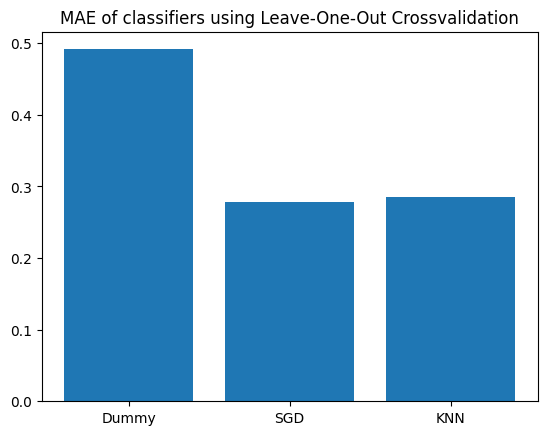

In [12]:
performances_pipeline1 = [
    ('Dummy', dummy_mae_over_cv),
    ('SGD', sgd_mae_over_cv),
    ('KNN', knn_mae_over_cv)
]

plt.title('MAE of classifiers using Leave-One-Out Crossvalidation')
plt.bar([x[0] for x in performances_pipeline1], [x[1] for x in performances_pipeline1])

In [43]:
data_autograder = pd.read_csv('football_autograder.csv')
data_autograder.head()

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,27.0,190.0,78.0,b'England',70.0,71.0,52.0,42.0,75.0,60.0,...,57.0,67.0,61.0,72.0,68.0,15.0,8.0,12.0,13.0,15.0
1,19.0,183.0,76.0,b'Republic of Ireland',59.0,77.0,45.0,20.0,53.0,60.0,...,66.0,55.0,69.0,59.0,57.0,8.0,11.0,10.0,6.0,11.0
2,20.0,172.0,67.0,b'China PR',48.0,53.0,40.0,34.0,38.0,52.0,...,57.0,56.0,70.0,35.0,43.0,12.0,6.0,9.0,7.0,12.0
3,28.0,170.0,65.0,b'Brazil',76.0,76.0,73.0,76.0,52.0,72.0,...,89.0,70.0,88.0,50.0,48.0,12.0,7.0,12.0,10.0,7.0
4,28.0,186.0,74.0,b'England',65.0,67.0,18.0,19.0,15.0,25.0,...,32.0,57.0,57.0,14.0,17.0,66.0,64.0,66.0,63.0,68.0


Pipeline 1 - SGD MAE: `0.278`

Pipeline 2 - KNN MAE: `0.286`

We will use it as the estimation for the autograder.

### 6. Compare pipelines

TODO: compare the two pipelines

In [ ]:
#TODO

### 7. Autograder Results


**KNN:** Autograder Results: 23/27 (Failed mae-score: #7 - #10)

**SGD:** Autograder Results: 24/27 (Failed mae-score: #8 - #10)

### 8. Tuning KNN and SGD w/ GridSearch

#### KNN GridSearch Pipeline

In [60]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# Grid Search for KNN
knn_pipeline = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", KNeighborsRegressor())]
)
# Grid Search Implementation
knn_param_grid = {
    'regressor__n_neighbors': [i for i in range(1, 200, 2)],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2, 3]
}
K = 100
cv = KFold(K, shuffle=True)

knn_gridsearch = GridSearchCV(estimator=knn_pipeline, 
                              param_grid=knn_param_grid,
                              scoring='neg_mean_squared_error',
                              cv=cv,
                              n_jobs=-1 # parallel processing
                              )

Justification for KNN Grid Search:
Overall, KNN does not have that many tunable hyperparameters that are relevant so GridSearch on KNN is not too computationally expensive.
- N-neighbors: Odd ranges (to avoid ambiguity for ties) from 1-200. We're doing 80/20 splits on input data, so, with N=4,000. We decided to go with 2*sqrt(N) as sqrt(N) is the general consensus for a good "starting" point.
- Weights: Has only two modes on weighing the neighbors based on distance weighing may be important since this is feature rich.
- P: determines the criteria for "nearest neighbor", either manhattan or euclidean or minkowski, included it as distance calculating criteria may have an effect due to being feature rich.

#### SGD GridSearch Pipeline

In [61]:
# Grid Search for KNN
sgd_pipeline = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", SGDRegressor(max_iter=5000))]
)
# Grid Search Implementation
# TODO: Find better ranges. It's very random right now.
sgd_param_grid = [
    {
    'regressor__penalty': ['l1', 'l2'],
    'regressor__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'regressor__learning_rate': ['optimal', 'invscaling', 'adaptive', 'constant'],
    'regressor__eta0': [1e-3, 1e-2, 1e-1],
    'regressor__average': [True, False]
    },
    {
    'regressor__penalty': ['elasticnet'],
    'regressor__l1_ratio' : [0.1, 0.25, 0.5, 0.75, 0.9],
    'regressor__alpha': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'regressor__learning_rate': ['optimal', 'invscaling', 'adaptive', 'constant'],
    'regressor__eta0': [1e-3, 1e-2, 1e-1],
    'regressor__average': [True, False]
    }
]

cv = KFold(10, shuffle=True, random_state=0)

sgd_gridsearch = GridSearchCV(estimator=sgd_pipeline, 
                              param_grid=sgd_param_grid,
                              scoring='neg_mean_squared_error',
                              cv=cv,
                              n_jobs=-1 # parallel processing
                              )

Justification for SGD GridSearch:
- penalty: The penalty term controls regularization type and therefore helps with model generalization. For our case, we will include all three supported settings, l1, l2 and elasticnet. The small caveat is that as elasticnet requires an extra hyperparameter for controlling the joint strength of l1 + l2, in our code, we separated the parameter grid to reduce the search space.
  - For Elasticnet, l1_ratio controls the strength of l1 vs l2. Chose ranges that compares varying strength between the two regularizers.

- alpha: The alpha term controls the regularization strength. Sensible range to avoid underfitting or weakening of regularization.

- learning_rate: Four settings. Included all as they may provide advantages one over the other.

- eta0: Initial learning rate is important in how the model converages, chose 3 sensible values.

- average: Controls whether the model uses an running average for the weights. This improves generalization but it may also hurt convergence.

#### GridSearch Results

In [63]:
model_score_results = []
for i in range(1): # 1 for now. Takes too long to execute..
    X_train, X_test, y_train, y_test = train_test_split(
        features_X, regression_target_Y, test_size=0.2
    )
    # sgd_gridsearch.fit(X_train, y_train)
    # print("Best parameters found", sgd_gridsearch.best_params_)
    # print("Best cross-validation score (Negative MSE)", sgd_gridsearch.best_score_)
    
    knn_gridsearch.fit(X_train, y_train)
    print("Best parameters found", knn_gridsearch.best_params_)
    print("Best cross-validation score", knn_gridsearch.best_score_)
    print()

Best parameters found {'regressor__n_neighbors': 25, 'regressor__p': 1, 'regressor__weights': 'distance'}
Best cross-validation score -0.1217981537297957



### Autograder 

In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [ ]:
data_autograder = pd.read_csv('football_autograder.csv')
data_autograder.head()


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,27.0,190.0,78.0,b'England',70.0,71.0,52.0,42.0,75.0,60.0,...,57.0,67.0,61.0,72.0,68.0,15.0,8.0,12.0,13.0,15.0
1,19.0,183.0,76.0,b'Republic of Ireland',59.0,77.0,45.0,20.0,53.0,60.0,...,66.0,55.0,69.0,59.0,57.0,8.0,11.0,10.0,6.0,11.0
2,20.0,172.0,67.0,b'China PR',48.0,53.0,40.0,34.0,38.0,52.0,...,57.0,56.0,70.0,35.0,43.0,12.0,6.0,9.0,7.0,12.0
3,28.0,170.0,65.0,b'Brazil',76.0,76.0,73.0,76.0,52.0,72.0,...,89.0,70.0,88.0,50.0,48.0,12.0,7.0,12.0,10.0,7.0
4,28.0,186.0,74.0,b'England',65.0,67.0,18.0,19.0,15.0,25.0,...,32.0,57.0,57.0,14.0,17.0,66.0,64.0,66.0,63.0,68.0


In [66]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = knn_mae_over_cv

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
# your predictions here should again be the $log_{10}(wage)$ of the football player, just as in the provided data. 
clf_sgd.fit(features_X, regression_target_Y)
predictions_autograder_data = clf_sgd.predict(X=data_autograder)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("baseSGD.txt", index=False, header=False)